# Retina-like RFs and their mosaic organization

This notebook generates the plots for Figure 3. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse, Rectangle
import seaborn as sns

from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%reload_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

In [3]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [4]:
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)

INFO:util:Processing batch 0 out of 4...


INFO:util:Processing batch 1 out of 4...


INFO:util:Processing batch 2 out of 4...


INFO:util:Processing batch 3 out of 4...


INFO:gaussian:CC criteria exclusion 219


INFO:gaussian:Location criteria exclusion 38


INFO:gaussian:Envelope criteria exclusion 12


## Cell types

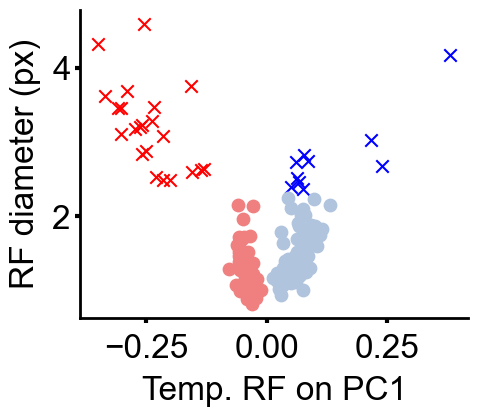

In [5]:
def plot_cell_types(ax):
    for i in range(4):
        query = rf_query.params_df["type"] == i
        ax.scatter(rf_query.params_df[query]["first_pc"], rf_query.params_df[query]["size"], s=80, marker=cell_type_marks[i], c=cell_type_colors_map[i])
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 24
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_xlabel("Temp. RF on PC1", fontsize=labelsize, labelpad=8)
    ax.set_ylabel("RF diameter (px)", fontsize=labelsize, labelpad=8)

cell_type_colors_map = {0: "red", 2: "lightcoral", 1: "blue", 3: "lightsteelblue"}
cell_type_marks = ["x", "x", "o", "o"]
cell_type_colors = [cell_type_colors_map[i] for i in rf_query.params_df["type"]]
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_cell_types(ax)

plt.savefig(f"{root}/figures/fig3/PC_dots.svg", format="svg", transparent=False, bbox_inches="tight")

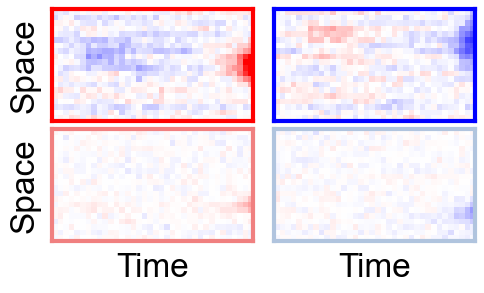

In [6]:
def plot_rf2d(i, c, ax):
    rf2d = rf_query.strfs[i].mean(2).T
    max_v = 0.5
    ax.imshow(rf2d, vmin=-max_v, vmax=max_v, cmap="bwr")
    for ax_name in ["left", "right", "bottom", "top"]:
        ax.spines[ax_name].set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(c)
    
fig, axs = plt.subplots(2, 2, figsize=(5, 3))
plot_rf2d(3, "red", axs[0, 0])
plot_rf2d(19, "blue", axs[0, 1])
plot_rf2d(9, "lightcoral", axs[1, 0])
plot_rf2d(104, "lightsteelblue", axs[1, 1])
labelsize = 24
axs[1, 0].set_xlabel("Time", fontsize=labelsize, labelpad=8)
axs[1, 1].set_xlabel("Time", fontsize=labelsize, labelpad=8)
axs[0, 0].set_ylabel("Space", fontsize=labelsize, labelpad=8)
axs[1, 0].set_ylabel("Space", fontsize=labelsize, labelpad=8)
fig.tight_layout()
plt.savefig(f"{root}/figures/fig3/rf2d.svg", format="svg", transparent=False, bbox_inches="tight")

## Parasol- and midget-like units & light response

In [7]:
pre_ms = 400
light_ms = 800
flash_query = analysis.FlashQuery(model, pre_ms=pre_ms, light_ms=light_ms, off_ms=light_ms, lum=0.5, model_n_frames=29)

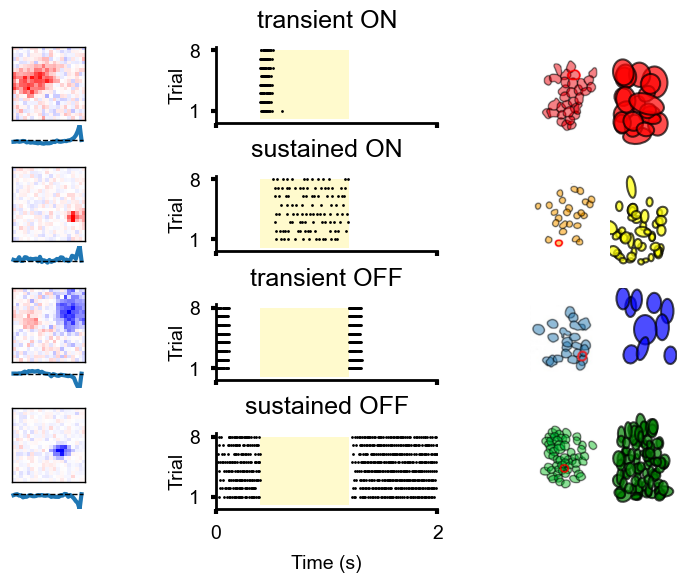

In [8]:
def to_grayscale(img):
    img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = (img - img.mean()) / img.max()
    
    return img

def plot_rf(rf, title, ax):
    if type(rf) == torch.Tensor:
        v = rf.abs().max()
    else:
        v = 1
    
    ax.imshow(rf, cmap="bwr", vmin=-v, vmax=v)
    ax.set_title(title, fontsize=18, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["left"].set_linewidth(1)
    ax.spines["right"].set_linewidth(1)

def plot_temp_profile(profile, ax):
    valid = ~torch.isnan(profile)
    scale = profile[valid].abs().max()
    ax.plot(profile / scale, linewidth=3)
    ax.plot([0, len(profile)], [0, 0], linestyle="dashed", c="black", linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])
    
    pmax = profile[valid].max()
    pmin = profile[valid].min()
    if pmax > -pmin:
        ax.set_ylim([-0.5, 1])
    else:
        ax.set_ylim([-1, 0.5])
        
    for ax_name in ["top", "bottom", "left", "right"]:
        ax.spines[ax_name].set_visible(False)
    
def plot_all_rf(rf, profile, spec, fig):
    rf_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=spec, height_ratios=[1, 0.3], hspace=0.1)
    rf_ax = plt.Subplot(fig, rf_spec[0])
    profile_ax = plt.Subplot(fig, rf_spec[1])
    fig.add_subplot(rf_ax)
    fig.add_subplot(profile_ax)
    plot_rf(rf, "", rf_ax)
    plot_temp_profile(profile, profile_ax)
    
def plot_light_response(raster_x, raster_y, title, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    ax.set_title(title, fontsize=18, pad=14)
    dt = 1000 / 240
    light_x = pre_ms / dt
    light_w = light_ms / dt
    rect = Rectangle((light_x, 0), light_w, 8, linewidth=1, edgecolor=None, facecolor="lemonchiffon", alpha=1) # lightyellow
    ax.add_patch(rect)
    
    ax.scatter(raster_x, raster_y+1, s=1, c="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.set_yticks([1, 8])
    ax.set_xticks([0, 480])
    ax.set_xlim([0, 480])
    ax.set_xticklabels([])
    ax.set_ylabel("Trial", fontsize=14, labelpad=2)
    
    return ax
    
def plot_mosaic(cell_type, color, dx, dy, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    q = rf_query.params_df["type"] == cell_type
    subparams_df = rf_query.params_df[q]
    
    ells = []
    for i in range(len(subparams_df)): #idx,idx+1,1
        x0 = subparams_df.iloc[i]["x0"]
        y0 = 20 - subparams_df.iloc[i]["y0"]
        sigmax = subparams_df.iloc[i]["sigmax"]
        sigmay = subparams_df.iloc[i]["sigmay"]
        p = subparams_df.iloc[i]["p"]
        ells.append(Ellipse(xy=(x0, y0),
                    width=1.5*sigmax, height=1.5*sigmay,
                    angle=-p*45, ec="black", fc="gray", linewidth=1.5))
    
    for e in ells:
        ax.add_artist(e)
        e.set_clip_box(ax.bbox)
        e.set_alpha(0.7)
        e.set_facecolor(color)
    
    ax.set_xlim(0+dx, 20+dx)
    ax.set_ylim(0+dy, 20+dy)
    ax.set_xticks([])
    ax.set_yticks([])
    
    for ax_name in ["left", "right", "bottom", "top"]:
        ax.spines[ax_name].set_visible(False)    
    
    return ax

def plot_macaque_mosaic(image, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    ax.imshow(image)
    ax.set_xticks([])
    ax.set_yticks([])
    for ax_name in ["top", "bottom", "left", "right"]:
        ax.spines[ax_name].set_visible(False) 
    
fig = plt.figure(figsize=(10, 6))
space = 0.25
fig_spec = gridspec.GridSpec(1, 2, wspace=0.4, hspace=0, width_ratios=[0.4, 1])
fig_spec2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[1], width_ratios=[1.5, 1], wspace=0.5)

rf_spec = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=fig_spec[0], width_ratios=[1, 1], wspace=0.4)
response_spec = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=fig_spec2[0], hspace=0.7)
mosaic_spec = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=fig_spec2[1], width_ratios=[1, 1], wspace=0.2)

on_parasol_idx = 17
on_midget_idx = 9
off_parasol_id = 19
off_midget_id = 26

macaque_on_parasol_mosaic = plt.imread(f"{root}/data/figures/on_parasol_mosaic.png")
macaque_on_midget_mosaic = plt.imread(f"{root}/data/figures/on_midget_mosaic.png")
macaque_off_parasol_mosaic = plt.imread(f"{root}/data/figures/off_parasol_mosaic.png")
macaque_off_midget_mosaic = plt.imread(f"{root}/data/figures/off_midget_mosaic.png")

on_parasol_profile = torch.cat([torch.Tensor([*rf_query.strfs.mean((2, 3))[on_parasol_idx].tolist(), 0])])
on_midget_profile  = torch.cat([torch.Tensor([*rf_query.strfs.mean((2, 3))[on_midget_idx].tolist(), 0])])
off_parasol_profile = torch.cat([torch.Tensor([*rf_query.strfs.mean((2, 3))[off_parasol_id].tolist(), 0])])
off_midget_profile  = torch.cat([torch.Tensor([*rf_query.strfs.mean((2, 3))[off_midget_id].tolist(), 0])])

plot_all_rf(rf_query.spatial_rfs[on_parasol_idx], on_parasol_profile, rf_spec[0, 1], fig)
plot_all_rf(rf_query.spatial_rfs[on_midget_idx], on_midget_profile, rf_spec[1, 1], fig)
plot_all_rf(rf_query.spatial_rfs[off_parasol_id], off_parasol_profile, rf_spec[2, 1], fig)
plot_all_rf(rf_query.spatial_rfs[off_midget_id], off_midget_profile, rf_spec[3, 1], fig)

plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[on_parasol_idx]["og_index"]), "transient ON", response_spec[0], fig)
plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[on_midget_idx]["og_index"]), "sustained ON", response_spec[1], fig)
plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[off_parasol_id]["og_index"]), "transient OFF", response_spec[2], fig)
ax = plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[off_midget_id]["og_index"]), "sustained OFF", response_spec[3], fig)
ax.set_xticklabels([0, 2])
ax.set_xlabel("Time (s)", fontsize=14, labelpad=8)

plot_macaque_mosaic(macaque_on_parasol_mosaic, mosaic_spec[0, 0], fig)
plot_macaque_mosaic(macaque_on_midget_mosaic, mosaic_spec[1, 0], fig)
plot_macaque_mosaic(macaque_off_parasol_mosaic, mosaic_spec[2, 0], fig)
plot_macaque_mosaic(macaque_off_midget_mosaic, mosaic_spec[3, 0], fig)

plot_mosaic(0, "red", 1, 4, mosaic_spec[0, 1], fig)
plot_mosaic(2, "yellow", 1, 3, mosaic_spec[1, 1], fig)
plot_mosaic(1, "blue", 0, 2, mosaic_spec[2, 1], fig)
plot_mosaic(3, "green", 0, 2, mosaic_spec[3, 1], fig)
plt.savefig(f"{root}/figures/fig3/main.svg", format="svg", transparent=False, bbox_inches="tight")


## Cell counts

In [9]:
def plot_counts(left_name, right_name, left_count, right_count, ax):
    sns.barplot(pd.DataFrame({left_name: [left_count], right_name: [right_count]}), ax=ax)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 30
    ax.set_ylim([0, 150])
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=labelsize, rotation=45, ha="right")
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)

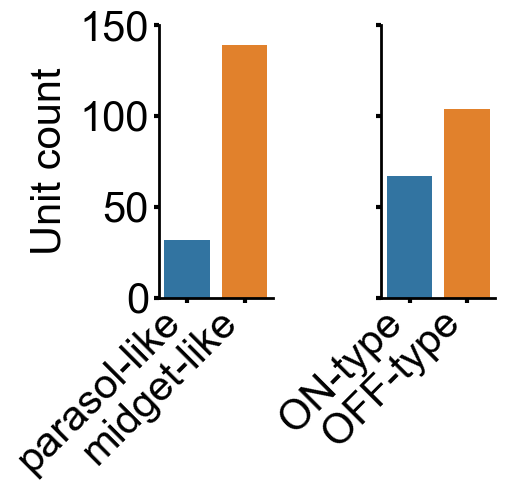

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(5, 5), sharey=True)

midget_count = rf_query.params_df["type"].isin([2, 3]).sum()
parasol_count = rf_query.params_df["type"].isin([0, 1]).sum()
plot_counts("parasol-like", "midget-like", parasol_count, midget_count, axs[0])

on_count = rf_query.params_df["type"].isin([0, 2]).sum()
off_count = rf_query.params_df["type"].isin([1, 3]).sum()
plot_counts("ON-type", "OFF-type", on_count, off_count, axs[1])
labelsize = 30
axs[0].set_ylabel("Unit count", fontsize=labelsize, labelpad=8)
fig.tight_layout()
plt.savefig(f"{root}/figures/fig3/unit_counts.svg", format="svg", transparent=False, bbox_inches="tight")

## Membrane time constant distribution

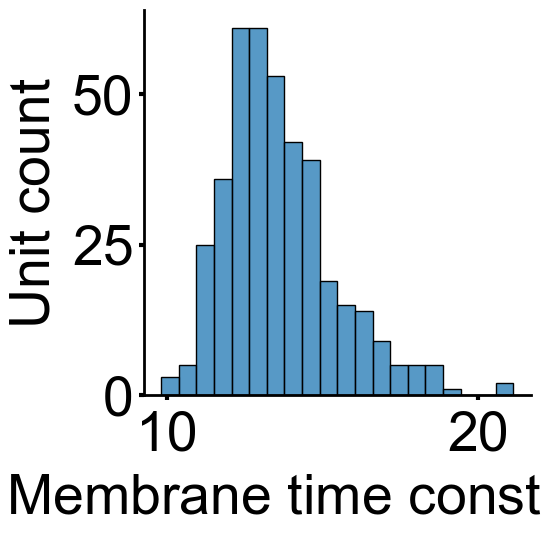

In [11]:
def plot_mem_distribution(time_constants, ax):
    sns.histplot(time_constants, ax=ax)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 40
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_xlabel("Membrane time constant $\\tau$", fontsize=labelsize, labelpad=8)
    ax.set_ylabel("Unit count", fontsize=labelsize, labelpad=8)
    
dt = 1000/240
time_constants = -dt / np.log(model._neurons.beta.cpu().detach())
    
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_mem_distribution(time_constants, ax)
plt.savefig(f"{root}/figures/fig3/mem_dist.svg", format="svg", transparent=False, bbox_inches="tight")